STEP 1: Unzip Your Dataset

In [1]:
import zipfile

zip_path = "/Machine_project.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted ✅")

Dataset extracted ✅


STEP 2: Check Folder Structure

In [ ]:
import os

base_path = "Machine_project"

for root, dirs, files in os.walk(base_path):
    print("📁", root)
    for f in files[:3]:  # show few files only
        print("   📄", f)

📁 /content/data/Machine_project
📁 /content/data/Machine_project/Normal
   📄 99.mat
   📄 97.mat
   📄 98.mat
📁 /content/data/Machine_project/.dist
📁 /content/data/Machine_project/s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Data
📁 /content/data/Machine_project/s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Data/IR
📁 /content/data/Machine_project/s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Data/IR/007
   📄 105_0.mat
   📄 107_2.mat
   📄 108_3.mat
📁 /content/data/Machine_project/s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Data/IR/021
   📄 209_0.mat
   📄 211_2.mat
   📄 210_1.mat
📁 /content/data/Machine_project/s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Data/IR/028
   📄 3004_3.mat
   📄 3002_1.mat
   📄 3003_2.mat
📁 /content/data/Machine_project/s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Data/IR/014
   📄 170_1.mat
   📄 172_3.mat
   📄 171_2.mat
📁 /content/data/Machine_project/s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Da

Step 3 : Load One .mat File (IMPORTANT CHECK)

In [3]:
import scipy.io

# Pick one file manually
sample_file = None

for root, dirs, files in os.walk(base_path):
    for f in files:
        if f.endswith(".mat"):
            sample_file = os.path.join(root, f)
            break
    if sample_file:
        break

print("Sample file:", sample_file)

data = scipy.io.loadmat(sample_file)
print("Keys:", data.keys())

Sample file: /content/data/Machine_project/Normal/99.mat
Keys: dict_keys(['__header__', '__version__', '__globals__', 'ans', 'X098_DE_time', 'X098_FE_time', 'X099_DE_time', 'X099_FE_time'])


STEP 4: Extract Signal

In [4]:
def extract_signal(data):
    for key in data:
        if "DE_time" in key:
            return data[key].flatten()

In [5]:
signal = extract_signal(data)
print("Signal length:", len(signal))

Signal length: 483903


STEP 5: Add Segmentation

In [6]:
# STEP 5: Signal Segmentation ONLY (NO FEATURES)

import numpy as np

def segment_signal(signal, window_size=2048, step=1024):
    segments = []
    for start in range(0, len(signal) - window_size, step):
        seg = signal[start:start + window_size]

        # Normalize each segment
        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-8)

        segments.append(seg)

    return segments

STEP 6: Create Dataset (X, y)

In [7]:
# STEP 6: Create Dataset (RAW SIGNAL for CNN)

import scipy.io
import os

X = []
y = []

main_fault_path = os.path.join(base_path, "s-whynot CWRU-dataset main 12k_Drive_End_Bearing_Fault_Data")
normal_path = os.path.join(base_path, "Normal")

# NORMAL
for file in os.listdir(normal_path):
    if file.endswith(".mat"):
        file_path = os.path.join(normal_path, file)
        try:
            data = scipy.io.loadmat(file_path)
            signal = extract_signal(data)
            segments = segment_signal(signal)

            for seg in segments:
                X.append(seg)
                y.append("Normal")
        except:
            continue

# FAULTS
for fault_type in os.listdir(main_fault_path):
    fault_path = os.path.join(main_fault_path, fault_type)

    if not os.path.isdir(fault_path):
        continue

    for root, dirs, files in os.walk(fault_path):
        for file in files:
            if file.endswith(".mat"):
                file_path = os.path.join(root, file)
                try:
                    data = scipy.io.loadmat(file_path)
                    signal = extract_signal(data)
                    segments = segment_signal(signal)

                    for seg in segments:
                        X.append(seg)
                        y.append(fault_type)
                except:
                    continue

print("Total samples:", len(X))
print("Segment shape:", np.array(X).shape)

Total samples: 8703
Segment shape: (8703, 2048)


STEP 7: Lable encoding + split

In [8]:
# STEP 7: Encode Labels + Train-Test Split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

X = np.array(X)

encoder = LabelEncoder()
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Add channel dimension for CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("Train shape:", X_train.shape)

Train shape: (6962, 2048, 1)


STEP 8: CNN Model

In [9]:
# STEP 8: CNN MODEL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(16, kernel_size=3, activation='relu', input_shape=(2048,1)),
    MaxPooling1D(2),

    Conv1D(32, kernel_size=3, activation='relu'),
    MaxPooling1D(2),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(4, activation='softmax')  # 4 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2046, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1023, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1021, 32)       │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 510, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16320)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,044,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,046,436 (3.99 MB)

 Trainable params: 1,046,436 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

STEP 9: Train CNN

In [ ]:
# STEP 9: Train CNN

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Save the model
model.save('bearing_fault_model.h5')
print("Model saved as bearing_fault_model.h5")

# Save the label encoder
import joblib
joblib.dump(encoder, 'label_encoder.pkl')
print("Label encoder saved as label_encoder.pkl")

Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.6860 - loss: 0.6869 - val_accuracy: 0.9121 - val_loss: 0.3135
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9022 - loss: 0.2651 - val_accuracy: 0.9316 - val_loss: 0.1984
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9448 - loss: 0.1562 - val_accuracy: 0.9615 - val_loss: 0.1231
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.9622 - loss: 0.0996 - val_accuracy: 0.9604 - val_loss: 0.1128
Epoch 5/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9691 - loss: 0.0909 - val_accuracy: 0.9213 - val_loss: 0.2325
Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9714 - loss: 0.0866 - val_accuracy: 0.8805 - val_loss: 0.2759
Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.9736 - loss: 0.0772 - val_accuracy: 0.9776 - val_loss: 0.0708
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9795 - loss: 0.0623 - 

STEP 10: Evaluation

In [11]:
# STEP 10: Evaluate

loss, accuracy = model.evaluate(X_test, y_test)
print("CNN Accuracy:", accuracy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9862 - loss: 0.0488
CNN Accuracy: 0.986214816570282


PREDICTION + REPORT

In [12]:
# STEP 11: Predictions

import numpy as np
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       376
           1       0.98      0.97      0.98       376
           2       1.00      1.00      1.00       330
           3       0.99      1.00      0.99       659

    accuracy                           0.99      1741
   macro avg       0.99      0.98      0.99      1741
weighted avg       0.99      0.99      0.99      1741



STEP 12: Detailed Evaluation

In [13]:
# STEP 12: Classification Report

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       376
           1       0.98      0.97      0.98       376
           2       1.00      1.00      1.00       330
           3       0.99      1.00      0.99       659

    accuracy                           0.99      1741
   macro avg       0.99      0.98      0.99      1741
weighted avg       0.99      0.99      0.99      1741

Confusion Matrix:
 [[365   5   0   6]
 [  8 366   0   2]
 [  0   0 330   0]
 [  2   1   0 656]]


Step 13: Simulate Federated Clients

In [14]:
# STEP 13: Create Federated Clients

import numpy as np

NUM_CLIENTS = 3

client_X = np.array_split(X_train, NUM_CLIENTS)
client_y = np.array_split(y_train, NUM_CLIENTS)

for i in range(NUM_CLIENTS):
    print(f"Client {i+1} data:", client_X[i].shape)

Client 1 data: (2321, 2048, 1)
Client 2 data: (2321, 2048, 1)
Client 3 data: (2320, 2048, 1)


STEP 14: Create Model Function

In [15]:
# STEP 14: Define Model Builder

def create_model():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

    model = Sequential([
        Conv1D(16, 3, activation='relu', input_shape=(2048,1)),
        MaxPooling1D(2),

        Conv1D(32, 3, activation='relu'),
        MaxPooling1D(2),

        Flatten(),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

STEP 15: Federated Averaging

In [16]:
# STEP 15: Federated Averaging

def federated_avg(weights_list):
    avg_weights = []

    for weights in zip(*weights_list):
        avg_weights.append(np.mean(weights, axis=0))

    return avg_weights

STEP 16: Federated Training Loop

In [28]:
# STEP 16: Method 1 - Federated Training (Correct)

method1_acc = []

ROUNDS = 5
EPOCHS = 2

global_model = create_model()

for round_num in range(ROUNDS):
    print(f"\n🔁 Round {round_num+1}")

    local_weights = []

    for i in range(NUM_CLIENTS):
        print(f"  Training Client {i+1}")

        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        local_model.fit(
            client_X[i], client_y[i],
            epochs=EPOCHS,
            batch_size=32,
            verbose=0
        )

        local_weights.append(local_model.get_weights())

    # ✅ Aggregate
    new_weights = federated_avg(local_weights)
    global_model.set_weights(new_weights)

    # ✅ Evaluate AFTER aggregation
    loss, acc = global_model.evaluate(X_test, y_test, verbose=0)

    # ✅ Store accuracy HERE (correct place)
    method1_acc.append(acc)

    print(f"  Global Accuracy: {acc:.4f}")

# ✅ Final accuracy
final_acc_m1 = method1_acc[-1]


🔁 Round 1
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.7295

🔁 Round 2
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9294

🔁 Round 3
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9742

🔁 Round 4
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9805

🔁 Round 5
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9862


# STEP 16A: Method 2 - Federated Averaging


In [18]:
# STEP 16A: Method 2 - Federated Averaging

ROUNDS = 5
EPOCHS = 2

global_model = create_model()

method2_acc = []

for round_num in range(ROUNDS):
    print(f"\n🔁 Round {round_num+1}")

    local_weights = []

    for i in range(NUM_CLIENTS):
        print(f"  Training Client {i+1}")

        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        local_model.fit(
            client_X[i], client_y[i],
            epochs=EPOCHS,
            batch_size=32,
            verbose=0
        )

        local_weights.append(local_model.get_weights())

    # ✅ FedAvg Aggregation
    new_weights = federated_avg(local_weights)
    global_model.set_weights(new_weights)

    loss, acc = global_model.evaluate(X_test, y_test, verbose=0)
    method2_acc.append(acc)

    print(f"  Global Accuracy: {acc:.4f}")

# Save final accuracy
final_acc_m2 = method2_acc[-1]


🔁 Round 1
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.5727

🔁 Round 2
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.8754

🔁 Round 3
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9374

🔁 Round 4
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9604

🔁 Round 5
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9655


In [19]:
# Smoothed Aggregation Function

def smoothed_aggregation(local_weights, prev_weights, alpha=0.7):
    avg_weights = []

    for weights in zip(*local_weights):
        avg_weights.append(np.mean(weights, axis=0))

    new_weights = []
    for prev, new in zip(prev_weights, avg_weights):
        new_weights.append(alpha * prev + (1 - alpha) * new)

    return new_weights

In [20]:
# STEP 16B: Method 3 - Smoothed Aggregation

global_model = create_model()   # 🔥 RESET MODEL

method3_acc = []

prev_weights = global_model.get_weights()

for round_num in range(ROUNDS):
    print(f"\n🔁 Round {round_num+1}")

    local_weights = []

    for i in range(NUM_CLIENTS):
        print(f"  Training Client {i+1}")

        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        local_model.fit(
            client_X[i], client_y[i],
            epochs=EPOCHS,
            batch_size=32,
            verbose=0
        )

        local_weights.append(local_model.get_weights())

    # ✅ Smoothed Aggregation
    new_weights = smoothed_aggregation(local_weights, prev_weights)
    global_model.set_weights(new_weights)

    prev_weights = new_weights

    loss, acc = global_model.evaluate(X_test, y_test, verbose=0)
    method3_acc.append(acc)

    print(f"  Global Accuracy: {acc:.4f}")

# Save final accuracy
final_acc_m3 = method3_acc[-1]


🔁 Round 1
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.4601

🔁 Round 2
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.6525

🔁 Round 3
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.8116

🔁 Round 4
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.8880

🔁 Round 5
  Training Client 1
  Training Client 2
  Training Client 3
  Global Accuracy: 0.9081


In [21]:
# STEP 17: Final Comparison

print("✅ Method 2 (FedAvg) Accuracy:", final_acc_m2)
print("✅ Method 3 (Smoothed) Accuracy:", final_acc_m3)

✅ Method 2 (FedAvg) Accuracy: 0.9655370712280273
✅ Method 3 (Smoothed) Accuracy: 0.9080988168716431


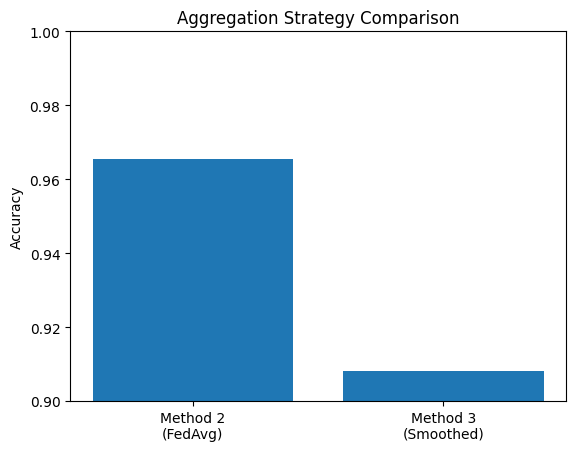

In [22]:
# STEP 18: Bar Chart Comparison

import matplotlib.pyplot as plt

methods = ["Method 2\n(FedAvg)", "Method 3\n(Smoothed)"]
accuracy = [final_acc_m2, final_acc_m3]

plt.figure()
plt.bar(methods, accuracy)
plt.title("Aggregation Strategy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()



```
# This is formatted as code
```

STEP 17: Final Evaluation

In [23]:
# STEP 17: Final Evaluation

loss, accuracy = global_model.evaluate(X_test, y_test)
print("Final Federated Model Accuracy:", accuracy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9081 - loss: 0.3762
Final Federated Model Accuracy: 0.9080988168716431


In [24]:
# STEP 19: Final Evaluation (All Methods)

print("\n📊 Final Results:")
print("Method 2 (FedAvg):", final_acc_m2)
print("Method 3 (Smoothed):", final_acc_m3)


📊 Final Results:
Method 2 (FedAvg): 0.9655370712280273
Method 3 (Smoothed): 0.9080988168716431


In [29]:
print("\n📊 Final Results:")
print("Method 1 (Baseline FedAvg):", final_acc_m1)
print("Method 2 (FedAvg):", final_acc_m2)
print("Method 3 (Smoothed):", final_acc_m3)


📊 Final Results:
Method 1 (Baseline FedAvg): 0.986214816570282
Method 2 (FedAvg): 0.9655370712280273
Method 3 (Smoothed): 0.9080988168716431


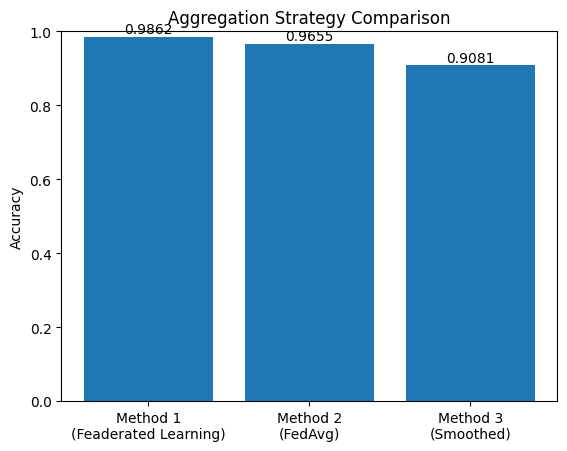

In [31]:
methods = [
    "Method 1\n(Feaderated Learning)",
    "Method 2\n(FedAvg)",
    "Method 3\n(Smoothed)"
]

accuracy = [final_acc_m1, final_acc_m2, final_acc_m3]

plt.figure()
plt.bar(methods, accuracy)

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.title("Aggregation Strategy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.show()